# Active Learning GCAD — End-to-End Walkthrough

This notebook demonstrates the complete pipeline in a single file:

1. **Configure** — set all parameters via `ActiveLearningConfig`
2. **Load circuits** — parse GCAD Pareto front, select top topologies
3. **Define ground truth** — create a synthetic "hidden reality" to calibrate against
4. **Run Active Learning** — OED + ABC inference loop
5. **Visualize results** — convergence, posterior, phenotypic comparison
6. **Update GCAD library** — write calibrated parameters back to the parts database

> For step-by-step notebooks with intermediate saves, see `notebooks/01` through `notebooks/06`.

## 0. Setup

In [8]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

from gcad.circuit import Topo  # required for safe pickle deserialization
from gcad.equations import system_equations_DsRed_pop
from gcad.loader import parts as nominal_parts, promo as promo_params

from active_learning.config import ActiveLearningConfig
from active_learning.loop import ActiveLearningLoop
from active_learning.gcad_utils import update_gcad_library

print("Working directory:", os.getcwd())
print(f"Nominal parts loaded: {len(nominal_parts)} parts")

Working directory: c:\Users\KuangQi\Desktop\temp\ActiveLearning-GCAD
Nominal parts loaded: 24 parts


## 1. Configure

All pipeline settings live in a single `ActiveLearningConfig` object.
Edit the values below to change ensemble size, budget, noise level, etc.

In [9]:
config = ActiveLearningConfig(
    # AL loop control
    max_cycles       = 8,
    ensemble_size    = 150,
    spread_factor    = 2.0,        # prior width: parameters sampled +/- log(2.0) from nominal
    dist_type        = 'lognormal',

    # Experimental budget per cycle
    budget_circuits  = 2,
    budget_dosages   = 2,
    dosages          = list(np.round(np.arange(0.2, 4.2, 0.4), 2)),

    # Lab noise
    measurement_noise_std = 5.0,   # % of signal peak

    # ABC inference
    selection_ratio     = 0.2,     # keep top 20% of models each cycle
    perturbation_scale  = 0.1,     # initial mutation scale (decays over cycles)
)

print(f"Ensemble size : {config.ensemble_size}")
print(f"Max cycles    : {config.max_cycles}")
print(f"Budget        : {config.budget_circuits} circuits x {config.budget_dosages} dosages")
print(f"Dosages       : {len(config.dosages)} candidates ({config.dosages[0]}x to {config.dosages[-1]}x)")

Ensemble size : 150
Max cycles    : 8
Budget        : 2 circuits x 2 dosages
Dosages       : 10 candidates (0.2x to 3.8x)


## 2. Load Circuits from GCAD

Load the Pareto-optimal circuits from a GCAD mining run and select the top M structurally distinct topologies.

**Option A** — parse a GCAD results folder directly (set `GCAD_OUTPUT` below).
**Option B** — load from `selected_M_circuits.pkl` produced by `notebooks/01`.

> To run GCAD first, use `active_learning.gcad_utils.run_gcad_miner()` or see `notebooks/06`.

In [10]:
import pandas as pd

def abstract_edges(edge_list):
    generic = []
    for u, v in edge_list:
        src = 'P1' if u == 'P1' else ('A' if u.startswith('Z') else ('R' if u.startswith('I') else u))
        tgt = 'Rep' if v == 'Rep' else ('A' if v.startswith('Z') else ('R' if v.startswith('I') else v))
        generic.append((src, tgt))
    return tuple(sorted(generic))

def load_circuits_from_folder(folder, m_target=3):
    df = pd.read_pickle(os.path.join(folder, "final_objectives_df.pkl"))
    with open(os.path.join(folder, "final_population.pkl"), "rb") as f:
        pop = pickle.load(f)
    df['circuit_object'] = [ind[0] for ind in pop]
    if df['prominence_rel'].mean() < 0:
        df['prominence_rel'] = -df['prominence_rel']
    df['abstract_sig'] = df['circuit_object'].apply(lambda c: abstract_edges(c.edge_list))
    valid = df[df['prominence_rel'] > 0.1]
    if len(valid) == 0:
        valid = df
    top_archs = valid['abstract_sig'].value_counts().head(m_target).index.tolist()
    return {f"Circuit_{i+1}": valid[valid['abstract_sig'] == a].sort_values('prominence_rel', ascending=False).iloc[0]['circuit_object']
            for i, a in enumerate(top_archs)}

In [11]:
GCAD_OUTPUT = os.path.join("data", "gcad_results")

if os.path.exists(os.path.join(GCAD_OUTPUT, "final_objectives_df.pkl")):
    circuit_dict = load_circuits_from_folder(GCAD_OUTPUT, m_target=3)
    print(f"Loaded {len(circuit_dict)} circuits from '{GCAD_OUTPUT}'.")
elif os.path.exists("selected_M_circuits.pkl"):
    with open(os.path.join("data", "selected_M_circuits.pkl"), "rb") as f:
        circuits_list = pickle.load(f)
    circuit_dict = {f"Circuit_{i+1}": c for i, c in enumerate(circuits_list)}
    print(f"Loaded {len(circuit_dict)} circuits from 'selected_M_circuits.pkl'.")
else:
    raise FileNotFoundError("No circuits found. Run GCAD first or place results in 'data/gcad_results/'.")

for name, c in circuit_dict.items():
    print(f"  {name}: edges={c.edge_list}")

Loaded 3 circuits from 'data\gcad_results'.
  Circuit_1: edges=[('P1', 'Z6'), ('Z6', 'Z6'), ('Z6', 'Rep'), ('Z6', 'I13'), ('I13', 'Z6')]
  Circuit_2: edges=[('P1', 'Z6'), ('Z6', 'Z6'), ('Z6', 'Rep'), ('Z6', 'I13'), ('I13', 'Z6'), ('I13', 'Rep')]
  Circuit_3: edges=[('P1', 'Z6'), ('P1', 'I13'), ('Z6', 'Z6'), ('Z6', 'Rep'), ('Z6', 'I13'), ('I13', 'Z6')]


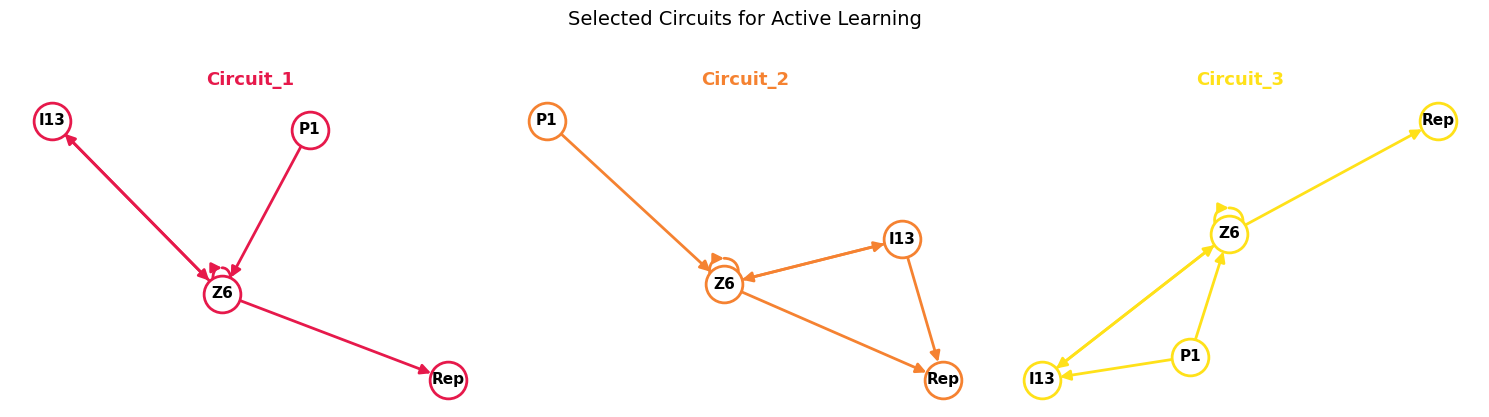

In [12]:
COLORS = ['#e6194B', '#f58231', '#ffe119', '#3cb44b', '#4363d8']
fig, axes = plt.subplots(1, len(circuit_dict), figsize=(5 * len(circuit_dict), 4))
if len(circuit_dict) == 1:
    axes = [axes]
for i, (name, circuit) in enumerate(circuit_dict.items()):
    ax = axes[i]
    color = COLORS[i % len(COLORS)]
    G = nx.DiGraph(circuit.edge_list)
    pos = nx.spring_layout(G, seed=25)
    nx.draw(G, pos, ax=ax, node_color='white', edgecolors=color, linewidths=2, node_size=700,
            with_labels=True, font_weight='bold', font_size=11, edge_color=color, width=2, arrowsize=15)
    ax.set_title(name, color=color, fontweight='bold', fontsize=13)
plt.suptitle("Selected Circuits for Active Learning", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## 3. Define the Hidden Ground Truth

In a real experiment, the "ground truth" is the actual biology you are measuring.
Here we simulate it by mutating specific kinetic parameters away from their nominal (textbook) values.

Edit the mutations below to test different calibration scenarios.

In [13]:
true_parts = {k: v.copy() if hasattr(v, 'copy') else v for k, v in nominal_parts.items()}

# Mutation 1: Z6 (Activator) — tighter binding, stronger activation
true_parts['Z6'] = np.array([0.015, 72.5, nominal_parts['Z6'][2]])

# Mutation 2: I13 (Inhibitor) — tighter binding
true_parts['I13'] = np.array([0.009])

print("Ground truth vs nominal:")
print(f"  Z6   nominal={nominal_parts['Z6']}  truth={true_parts['Z6']}")
print(f"  I13  nominal={nominal_parts['I13']}  truth={true_parts['I13']}")
print("  (All other parts remain at nominal values)")

Ground truth vs nominal:
  Z6   nominal=[2.52453350e-02 5.45902641e+01 2.64766428e-02]  truth=[1.50000000e-02 7.25000000e+01 2.64766428e-02]
  I13  nominal=[0.01476136]  truth=[0.009]
  (All other parts remain at nominal values)


## 4. Run the Active Learning Loop

`ActiveLearningLoop` orchestrates three components automatically each cycle:

- **Designer** — scores the full (circuit x dosage) grid by prediction variance and selects the most informative experiments within the budget
- **Lab** — simulates the selected experiments using the hidden truth + Gaussian noise
- **Learner** — scores the ensemble against all accumulated data (NMSE), keeps the top 20%, and resamples with exponentially-decaying perturbation

The loop runs for `max_cycles` iterations and returns the posterior mean parameter dictionary.

In [14]:
np.random.seed(42)

engine = ActiveLearningLoop(circuit_dict, true_parts, config)
calibrated_parts, history = engine.run()


[AL Engine] Initialization Complete. Dynamic Targets Identified: {'I13': [0], 'Z6': [0, 1, 2]}

 🚀 STARTING AL CYCLE 0


[Designer] Simulating Grid: 100%|██████████| 30/30 [01:56<00:00,  3.88s/exp]


[Designer] Selected Experiments: [('Circuit_3', 0.2), ('Circuit_3', 0.6), ('Circuit_1', 0.2), ('Circuit_1', 0.6)]

[Learner] Assessing 150 models against 4 experiments
[Learner] Selected top 30 candidates.
[Learner] Best Total NMSE: 3.0587e-02

 🚀 STARTING AL CYCLE 1


[Designer] Simulating Grid: 100%|██████████| 30/30 [01:51<00:00,  3.72s/exp]


[Designer] Selected Experiments: [('Circuit_3', 1.8), ('Circuit_3', 1.4), ('Circuit_1', 1.8), ('Circuit_1', 2.2)]

[Learner] Assessing 150 models against 4 experiments
[Learner] Selected top 30 candidates.
[Learner] Best Total NMSE: 1.1435e-02

 🚀 STARTING AL CYCLE 2


...

[Designer] Selected Experiments: [('Circuit_3', 0.6), ('Circuit_3', 0.2), ('Circuit_1', 0.6), ('Circuit_1', 1.0)]

[Learner] Assessing 150 models against 4 experiments
[Learner] Selected top 30 candidates.
[Learner] Best Total NMSE: 1.1962e-02

 🚀 STARTING AL CYCLE 6


[Designer] Simulating Grid: 100%|██████████| 30/30 [02:05<00:00,  4.20s/exp]


[Designer] Selected Experiments: [('Circuit_3', 0.6), ('Circuit_3', 0.2), ('Circuit_1', 1.0), ('Circuit_1', 0.6)]

[Learner] Assessing 150 models against 4 experiments
[Learner] Selected top 30 candidates.
[Learner] Best Total NMSE: 1.2459e-02

 🚀 STARTING AL CYCLE 7


[Designer] Simulating Grid: 100%|██████████| 30/30 [02:00<00:00,  4.03s/exp]


[Designer] Selected Experiments: [('Circuit_3', 0.6), ('Circuit_3', 0.2), ('Circuit_1', 0.6), ('Circuit_1', 0.2)]

[Learner] Assessing 150 models against 4 experiments
[Learner] Selected top 30 candidates.
[Learner] Best Total NMSE: 8.8705e-03

🎉 ACTIVE LEARNING LOOP FINISHED.

🎯 FINAL DISCOVERED PARAMETERS vs HIDDEN TRUTH:
   I13:
      AL Found: [0.011559]
      Truth:    [0.009]
   Z6:
      AL Found: [2.1546000e-02 6.1175506e+01 3.6537000e-02]
      Truth:    [1.5000e-02 7.2500e+01 2.6477e-02]

📄 Run summary automatically saved to: run_logs/AL_Run_20260616_0247.txt


## 5. Visualize Results

### 5a. Convergence

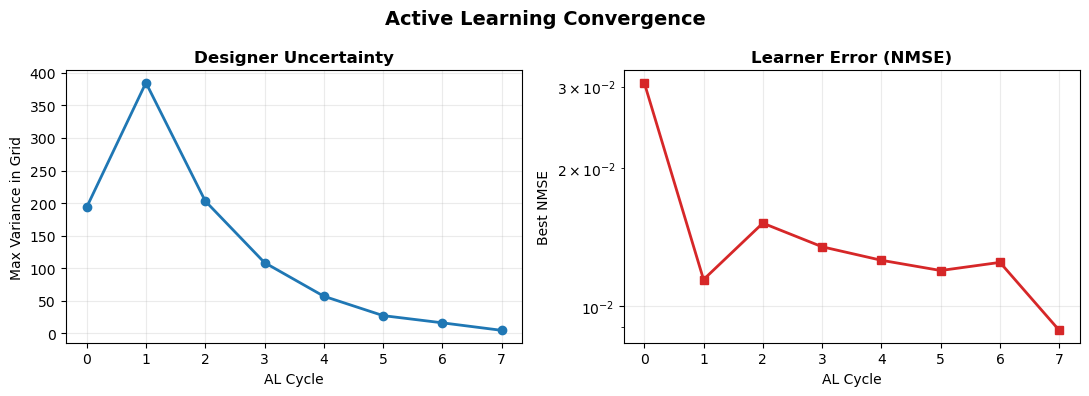

In [15]:
errors    = [h['error'] for h in history]
variances = [h['variance_max'] for h in history]
cycles    = list(range(len(history)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(cycles, variances, marker='o', color='#1f77b4', lw=2)
axes[0].set_title('Designer Uncertainty', fontweight='bold')
axes[0].set_xlabel('AL Cycle')
axes[0].set_ylabel('Max Variance in Grid')
axes[0].grid(True, alpha=0.25)

axes[1].plot(cycles, errors, marker='s', color='#d62728', lw=2)
axes[1].set_title('Learner Error (NMSE)', fontweight='bold')
axes[1].set_xlabel('AL Cycle')
axes[1].set_ylabel('Best NMSE')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.25)

plt.suptitle('Active Learning Convergence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5b. Calibrated Parameters vs Ground Truth

In [16]:
from active_learning.utils import generate_dynamic_targets
targets = generate_dynamic_targets(list(circuit_dict.values()))

print(f"{'Part':<10} {'Idx':<6} {'Nominal':>12} {'Truth':>12} {'AL Mean':>12} {'Rel Error':>11}")
print("-" * 58)
for part, indices in targets.items():
    for i in indices:
        nom = nominal_parts[part][i]
        tru = true_parts[part][i]
        cal = calibrated_parts[part][i]
        err = abs(cal - tru) / abs(tru) * 100
        print(f"{part:<10} [{i}]    {nom:>12.4f} {tru:>12.4f} {cal:>12.4f} {err:>9.1f}%")

Part       Idx         Nominal        Truth      AL Mean   Rel Error
----------------------------------------------------------
I13        [0]          0.0148       0.0090       0.0116      28.4%
Z6         [0]          0.0252       0.0150       0.0215      43.6%
Z6         [1]         54.5903      72.5000      61.1755      15.6%
Z6         [2]          0.0265       0.0265       0.0365      38.0%


### 5c. Phenotypic Comparison — Hidden Truth vs. Calibrated Parameters

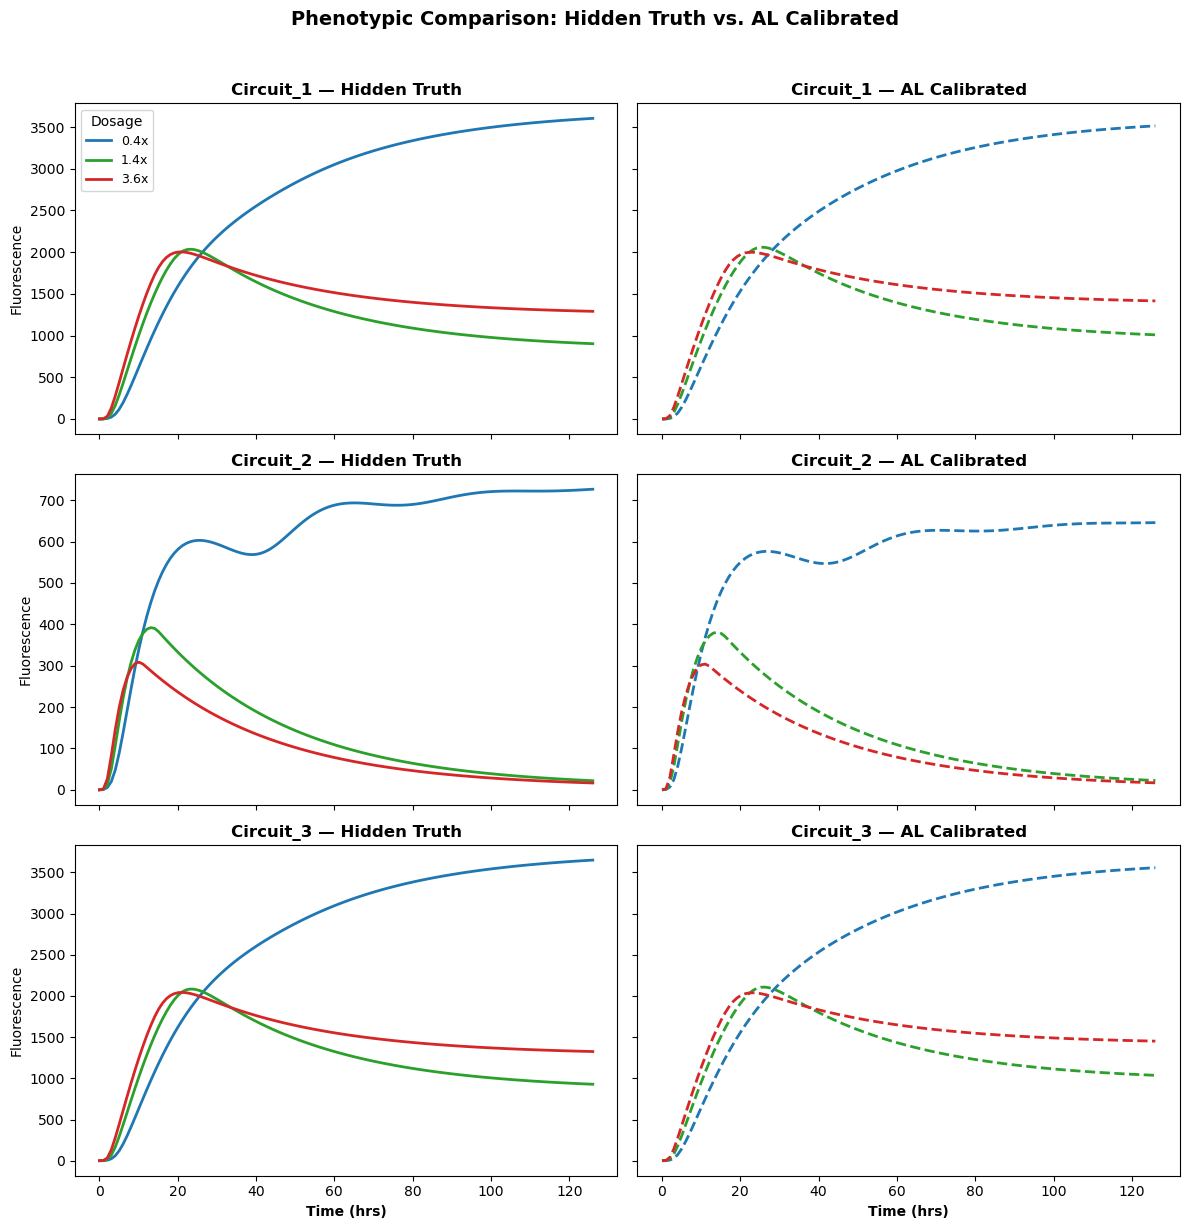

In [17]:
from scipy.integrate import odeint

discovered_parts = {k: v.copy() if hasattr(v, 'copy') else v for k, v in nominal_parts.items()}
for k, v in calibrated_parts.items():
    discovered_parts[k] = v

t_span       = config.get_t_span()
test_dosages = [0.4, 1.4, 3.6]
colors       = ['#1f77b4', '#2ca02c', '#d62728']

n = len(circuit_dict)
fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n), sharex=True, sharey='row')
if n == 1:
    axes = axes[None, :]

for row, (c_name, topo) in enumerate(circuit_dict.items()):
    for d_idx, dose in enumerate(test_dosages):
        sim_dose = {k: v * dose for k, v in topo.dose.items() if k != 'Rep'}
        if 'Rep' in topo.dose:
            sim_dose['Rep'] = topo.dose['Rep']
        temp = Topo(topo.edge_list, sim_dose, topo.promo_node)

        y_true = odeint(system_equations_DsRed_pop, np.zeros(temp.num_states * 2), t_span,
                        args=('on', np.ones(5), temp, promo_params, true_parts))[:, -1]
        y_cal  = odeint(system_equations_DsRed_pop, np.zeros(temp.num_states * 2), t_span,
                        args=('on', np.ones(5), temp, promo_params, discovered_parts))[:, -1]

        axes[row, 0].plot(t_span, y_true, color=colors[d_idx], lw=2, label=f"{dose}x")
        axes[row, 1].plot(t_span, y_cal,  color=colors[d_idx], lw=2, linestyle='--')

    axes[row, 0].set_title(f"{c_name} — Hidden Truth", fontweight='bold')
    axes[row, 1].set_title(f"{c_name} — AL Calibrated", fontweight='bold')
    axes[row, 0].set_ylabel("Fluorescence")
    if row == 0:
        axes[row, 0].legend(loc='upper left', fontsize=9, title='Dosage')

axes[-1, 0].set_xlabel("Time (hrs)", fontweight='bold')
axes[-1, 1].set_xlabel("Time (hrs)", fontweight='bold')
plt.suptitle("Phenotypic Comparison: Hidden Truth vs. AL Calibrated", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Update the GCAD Library

Write the calibrated parameters back to `gcad/data/parts.pkl`.
A backup of the nominal values is created automatically on the first call.

After this step, any new GCAD mining run will use the calibrated (more accurate) model.

In [18]:
update_gcad_library(calibrated_parts)


[GCAD] >> UPDATING GCAD LIBRARY:
   PART: I13
      Idx [0]: 0.0148  -->  0.0116  (-21.69%)
   PART: Z6
      Idx [0]: 0.0252  -->  0.0215  (-14.65%)
      Idx [1]: 54.5903  -->  61.1755  (+12.06%)
      Idx [2]: 0.0265  -->  0.0365  (+38.00%)
[GCAD] Library updated. Ready for next cycle.


---

## Next Steps

| Goal | Notebook |
|---|---|
| Step-by-step guided walkthrough | `notebooks/01` through `notebooks/06` |
| Minimal API demo (3 cells) | `notebooks/07_run_api.ipynb` |
| Full autonomous GCAD → AL → GCAD loop | `notebooks/08_full_loop.ipynb` |
| Understand each AL component in isolation | `examples/single_circuit_*.ipynb` |